In [83]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np
from matplotlib import pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [84]:
df = pd.read_csv("C:/Users/maman/OneDrive/שולחן העבודה/dataset-stroke-cleaned1.csv")

In [85]:
# Converting to boolean 
df["ever_married"] = df["ever_married"].map({"Yes": 1, "No": 0})
df["Residence_type"] = df["Residence_type"].map({"Rural": 1, "Urban": 0})

In [86]:
# Combine features
X = df.drop('stroke', axis=1)
y = df['stroke']

In [87]:
# Split the data into training, validation and test sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [88]:
# Division into types of variables
cat_cols = ['gender', 'work_type', 'smoking_status']
bin_cols = ['hypertension', 'heart_disease', 'Residence_type','ever_married']
num_cols = ['age', 'avg_glucose_level', 'bmi']

In [89]:
# Encode categorical features
ohe = OneHotEncoder(drop=None, sparse_output=False);
X_train_cat = ohe.fit_transform(X_train[cat_cols])
X_test_cat  = ohe.transform(X_test[cat_cols])

In [90]:
# Turn binary features into NumPy array for easy concatenation with other feature arrays
X_train_bin = X_train[bin_cols].to_numpy()
X_test_bin = X_test[bin_cols].to_numpy()

In [91]:
# Scale numerical features
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[num_cols])
X_test_num  = scaler.transform(X_test[num_cols])

In [92]:
# Combine
X_train_ready = np.hstack([X_train_cat, X_train_bin, X_train_num])
X_test_ready  = np.hstack([X_test_cat,  X_test_bin,  X_test_num])

In [93]:
# Create and train logistic regression mode
log_reg = LogisticRegression(max_iter=1000);
log_reg.fit(X_train_ready, y_train)

LogisticRegression(max_iter=1000)

In [95]:
# Predict labels for test set
y_pred = log_reg.predict(X_test_ready)

In [96]:
# Print classification metrics
print("Classification Report:\n", classification_report(y_test, y_pred, digits=3))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))

Classification Report:
               precision    recall  f1-score   support

           0      0.957     1.000     0.978       940
           1      0.000     0.000     0.000        42

    accuracy                          0.957       982
   macro avg      0.479     0.500     0.489       982
weighted avg      0.916     0.957     0.936       982

Confusion Matrix:
 [[940   0]
 [ 42   0]]
ROC AUC Score: 0.8136524822695036


C:\Users\maman\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\maman\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\maman\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [100]:
# Feature importance analysis
feature_names = list(ohe.get_feature_names_out(cat_cols)) + bin_cols + num_cols
coefs = pd.Series(log_reg.coef_[0], index=feature_names).sort_values(key=abs, ascending=False)

print("\n🔺 Features that increase stroke risk:")
print(coefs[coefs > 0].head(10))

print("\n🔻 Features that decrease stroke risk:")
print(coefs[coefs < 0].tail(10))


🔺 Features that increase stroke risk:
age                               1.658722
hypertension                      0.655611
work_type_children                0.315130
smoking_status_smokes             0.253713
heart_disease                     0.237036
avg_glucose_level                 0.207183
work_type_Private                 0.072334
bmi                               0.016949
smoking_status_formerly smoked    0.010707
dtype: float64

🔻 Features that decrease stroke risk:
work_type_Self-employed       -0.288544
ever_married                  -0.268836
smoking_status_Unknown        -0.248120
work_type_Govt_job            -0.137303
smoking_status_never smoked   -0.103591
gender_Male                   -0.071256
work_type_Never_worked        -0.048908
gender_Other                  -0.012927
Residence_type                -0.008990
gender_Female                 -0.003109
dtype: float64


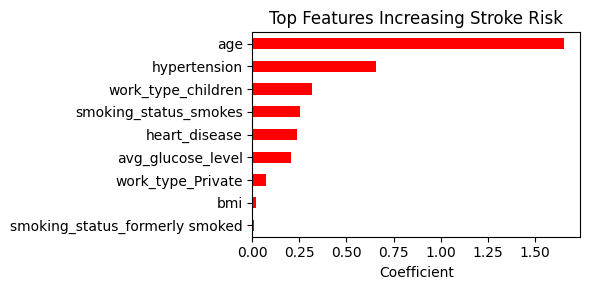

In [101]:
# Show the 10 features that increase risk
plt.figure(figsize=(6,3))
coefs[coefs > 0].head(10).plot(kind='barh', color='red')
plt.title("Top Features Increasing Stroke Risk")
plt.xlabel("Coefficient")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

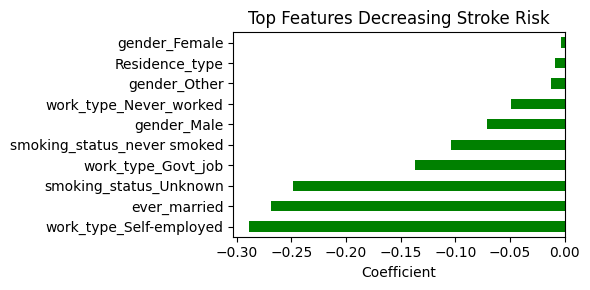

In [102]:
# Show the 10 features that reduce risk
plt.figure(figsize=(6,3))
coefs[coefs < 0].tail(10).plot(kind='barh', color='green')
plt.title("Top Features Decreasing Stroke Risk")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()